# Distillation Column Soft-Sensor
## Feature Scaling & ML Modeling

This notebook covers the complete machine learning pipeline:
- Feature scaling and preprocessing
- Baseline model development (Linear Regression, Random Forest)
- XGBoost model training and optimization
- Feature importance analysis
- Model comparison and evaluation
- Saving models for deployment

**Goal**: Build and compare multiple models to predict purity from process variables.

**Key Question**: Which model best captures the distillation process dynamics?

---
## Part 1: Setup & Data Loading

### 1.1 Import Libraries

**What you need to do:**
- Import libraries for data manipulation (pandas, numpy)
- Import libraries for scaling (sklearn.preprocessing)
- Import libraries for train/test splitting (sklearn.model_selection)
- Import libraries for model training:
  - Linear models (sklearn.linear_model)
  - Ensemble models (sklearn.ensemble)
  - XGBoost (xgboost)
- Import libraries for evaluation (sklearn.metrics)
- Import visualization libraries (matplotlib, seaborn)
- Import utilities for saving models (joblib)

**Question for you:** What's the difference between `from sklearn import X` and `import sklearn.X`?

In [184]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

import joblib

### 1.2 Configure Visualization Settings

**What you need to do:**
- Set matplotlib figure size defaults
- Set seaborn style (whitegrid, darkgrid, etc.)
- Configure display settings for better readability

**Question for you:** Why set these globally at the beginning?

In [158]:
# 1. Set Matplotlib figure size defaults (Width, Height in inches)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 12

# 2. Set Seaborn style and palette
sns.set_theme(style="whitegrid", palette="viridis")

# 3. Configure Pandas display settings for better readability
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.precision', 4)      # Round floats to 4 decimal places

### 1.3 Load Cleaned Data

In [105]:
from pathlib import Path

ROOT = Path.cwd().parent

DATA_DIR = ROOT / "data" 

X = pd.read_csv(DATA_DIR / 'X_ml_features.csv')
y = pd.read_csv(DATA_DIR / 'y_ml_target.csv')

In [106]:
print(X.shape)
print(y.shape)

(4168, 30)
(4168, 1)


In [107]:
X.head()

,T1,T5_lag5,T5_lag30,T5_lag60,L,F,T7,T1_lag10,hour_of_day_cos,T4_lag5,T5_lag1,T4_lag1,B,T13,T1_lag5,T4_lag60,hour_of_day_sin,T4_lag10,T1_lag240,T5_lag10,D,T4_lag30,T6,T5,T5_lag240,T4_lag240,T4,T14,T1_lag30,T1_lag60
0,350.82,350.99,350.99,350.99,780.0,600,351.14,350.82,1.000,350.94,350.99,350.94,340,354.75,350.82,350.94,0.000,350.94,350.89,350.99,260,350.94,351.06,350.99,351.16,351.08,350.94,362.92,350.82,350.82
1,350.82,350.99,350.99,350.99,780.0,600,351.14,350.82,1.000,350.94,350.99,350.94,340,354.75,350.82,350.94,0.026,350.94,350.86,350.99,260,350.94,351.06,350.99,351.09,351.02,350.94,362.92,350.82,350.82
2,350.82,350.99,350.99,350.99,780.0,600,351.14,350.82,0.999,350.94,350.99,350.94,340,354.75,350.82,350.94,0.052,350.94,350.85,350.99,260,350.94,351.06,350.99,351.05,350.99,350.94,362.92,350.82,350.82
3,350.82,350.99,350.99,350.99,780.0,600,351.14,350.82,0.997,350.94,350.99,350.94,340,354.75,350.82,350.94,0.078,350.94,350.84,350.99,260,350.94,351.06,350.99,351.03,350.97,350.94,362.92,350.82,350.82
4,350.82,350.99,350.99,350.99,780.0,600,351.14,350.82,0.995,350.94,350.99,350.94,340,354.75,350.82,350.94,0.105,350.94,350.83,350.99,260,350.94,351.06,350.99,351.02,350.96,350.94,362.92,350.82,350.82


In [108]:
y.head()

,Ethanol concentration
0,0.851
1,0.851
2,0.851
3,0.851
4,0.851


In [109]:
X.isnull().sum()

T1                 0
T5_lag5            0
T5_lag30           0
T5_lag60           0
L                  0
F                  0
T7                 0
T1_lag10           0
hour_of_day_cos    0
T4_lag5            0
T5_lag1            0
T4_lag1            0
B                  0
T13                0
T1_lag5            0
T4_lag60           0
hour_of_day_sin    0
T4_lag10           0
T1_lag240          0
T5_lag10           0
D                  0
T4_lag30           0
T6                 0
T5                 0
T5_lag240          0
T4_lag240          0
T4                 0
T14                0
T1_lag30           0
T1_lag60           0
dtype: int64

---
## Part 2: Train/Test Split

In [110]:
lenght = len(X)

X_train = X.iloc[:int(lenght*0.8)]
X_test = X.iloc[int(lenght*0.8):]

y_train = y.iloc[:int(lenght*0.8)]
y_test = y.iloc[int(lenght*0.8):]

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((3334, 30), (834, 30), (3334, 1), (834, 1))

---
## Part 3: Feature Scaling

### 3.1 Why Scale Features?

**What you need to understand:**
- Different features have different ranges (temperature: 50-150°C, reflux: 1-10)
- Some algorithms care about scale, others don't
- Linear models (Linear Regression, Logistic Regression) are sensitive to scale
- Tree-based models (Random Forest, XGBoost) are NOT sensitive to scale
- Neural networks NEED scaling

**Questions for you:**
1. "Why would Linear Regression care about feature scale?"
2. "Why don't tree-based models care?"
3. "Should you scale before or after train/test split?"

### 3.2 Choose and Fit Scaler

**What you need to think about:**
- StandardScaler: (x - mean) / std → ranges around 0 ± 3
- MinMaxScaler: (x - min) / (max - min) → ranges [0, 1]
- RobustScaler: handles outliers better using median and quartiles

**Critical Rule**: Fit scaler on TRAIN data only, then transform BOTH train and test!

**Why?** If you fit on all data (train + test), you're leaking information from test into train!

**Questions for you:**
1. "Which scaler makes sense for your distillation data?"
2. "What happens if you fit the scaler on test data instead of train?"
3. "Why must you use the SAME scaler for both train and test?"

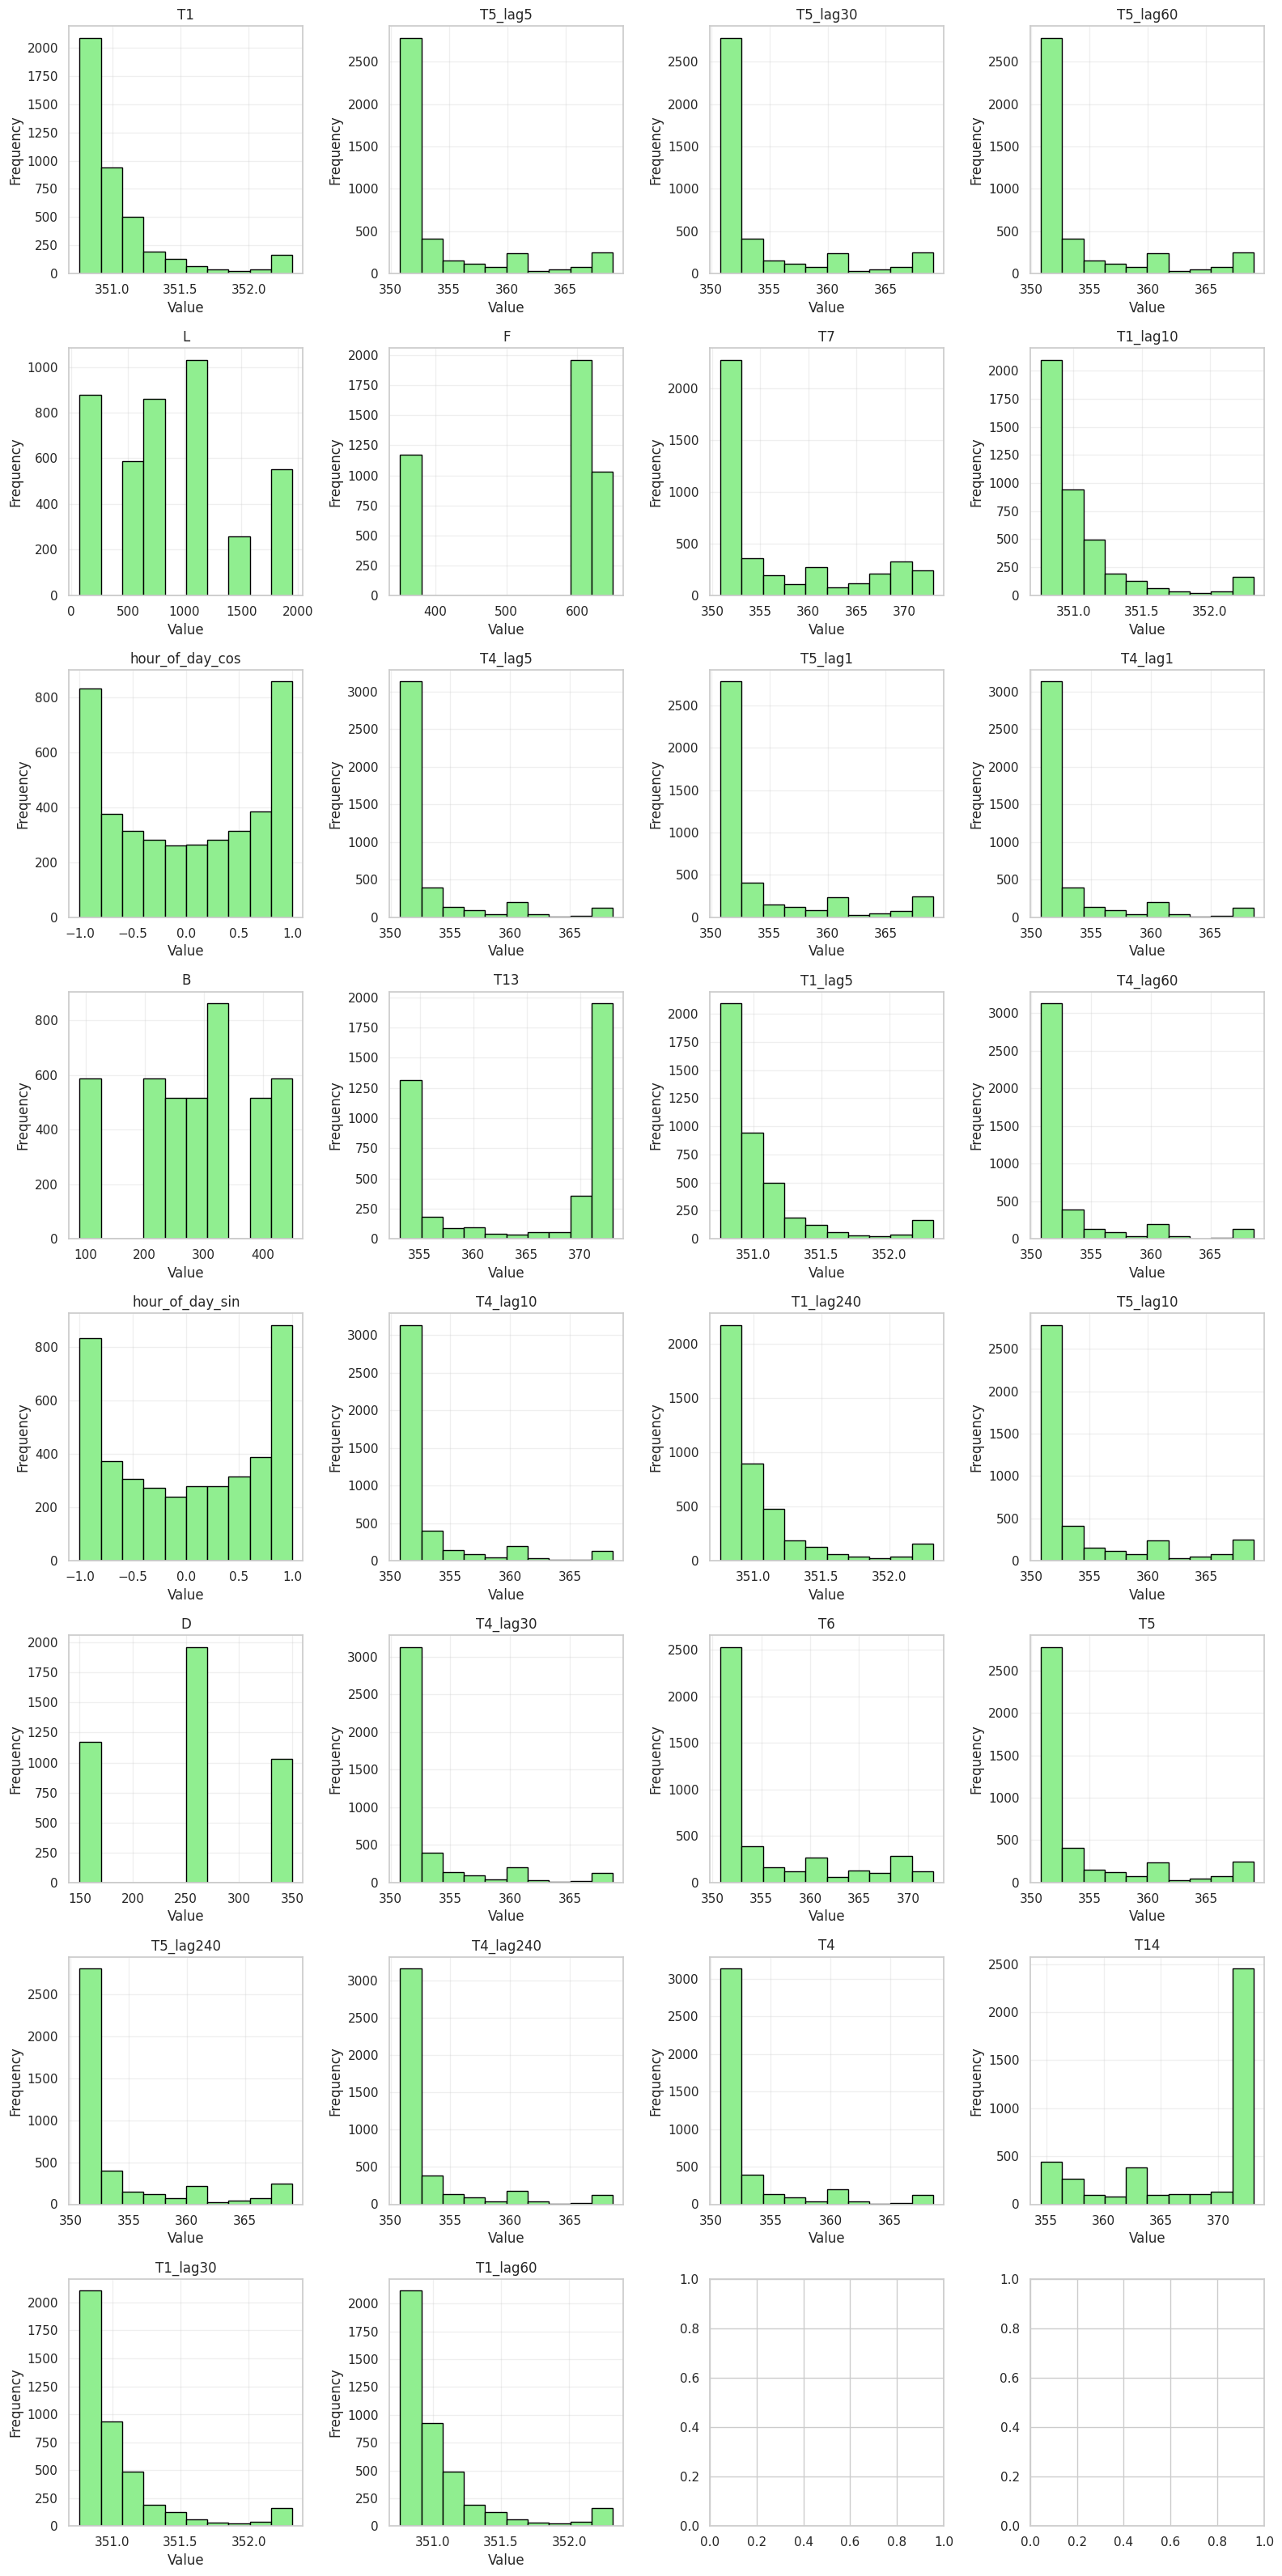

In [111]:
# Plot distributions of all features (excluding time_hours for clarity)
feature_cols_to_plot = [col for col in X.columns]
n_features = len(feature_cols_to_plot)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4*n_rows))
axes = axes.flatten()

for idx, col in enumerate(feature_cols_to_plot):
    axes[idx].hist(X[col], color='lightgreen', edgecolor='black')
    axes[idx].set_title(f'{col}')
    axes[idx].set_xlabel('Value')
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(alpha=0.3)


plt.tight_layout()
plt.show()

In [112]:
features_time = ['hour_of_day_sin', 'hour_of_day_cos'] # no scaling
features_minmax = ['L', 'F', 'B', 'D'] # min max scaling
features_robust = list(set(X.columns) - set(features_time) - set(features_minmax))  # robust scaling

In [113]:
preprocessor = ColumnTransformer(
    transformers=[
        ('robust_scaler', RobustScaler(), features_robust),
        ('minmax_scaler', MinMaxScaler(), features_minmax)
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
).set_output(transform='pandas')
pipe_preprocess = Pipeline(steps=[
    ('preprocessor', preprocessor)
])

pipe_preprocess

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('robust_scaler', ...), ('minmax_scaler', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'passthrough'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [114]:
X_train_scaled = pipe_preprocess.fit_transform(X_train)
X_test_scaled = pipe_preprocess.transform(X_test)

In [182]:
X_train_scaled.describe()

,T5_lag60,T4_lag1,T5,T7,T4,T1_lag5,T4_lag10,T1_lag60,T1_lag30,T4_lag240,T6,T1_lag10,T1,T5_lag5,T4_lag5,T5_lag240,T5_lag1,T5_lag30,T5_lag10,T4_lag30,T14,T1_lag240,T4_lag60,T13,L,F,B,D,hour_of_day_cos,hour_of_day_sin
count,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3334.0000,3.3340e+03,3.3340e+03
mean,0.9940,1.1491,0.9356,0.3683,1.1491,0.4929,1.1410,0.5187,0.5252,1.2988,0.5919,0.4925,0.4931,0.9355,1.1490,1.1331,0.9356,0.9622,0.9317,1.1530,-0.5020,0.5613,1.1991,-0.3505,0.3985,0.6323,0.5578,0.4944,-7.1762e-03,2.6474e-03
std,2.0509,2.7365,1.9535,0.6591,2.7365,1.3042,2.7180,1.3078,1.3058,3.0355,1.1299,1.3044,1.3041,1.9535,2.7366,2.3272,1.9535,1.9990,1.9461,2.7428,0.6760,1.3162,2.8373,0.4834,0.2927,0.4057,0.3070,0.3757,7.0523e-01,7.0914e-01
min,-0.2675,-0.3288,-0.2821,-0.1590,-0.3288,-0.5556,-0.3265,-0.5185,-0.5185,-0.2803,-0.2083,-0.5556,-0.5556,-0.2821,-0.3288,-0.2442,-0.2821,-0.2767,-0.2810,-0.3225,-1.8147,-0.4444,-0.3191,-1.0023,0.0000,0.0000,0.0000,0.0000,-1.0000e+00,-1.0000e+00
25%,-0.1824,-0.2123,-0.1971,-0.1264,-0.2123,-0.2963,-0.2177,-0.2593,-0.2593,-0.1667,-0.1565,-0.2963,-0.2963,-0.1971,-0.2123,-0.1567,-0.1971,-0.1937,-0.2002,-0.2127,-0.9822,-0.2222,-0.2057,-0.9117,0.2000,0.0000,0.3056,0.0000,-7.0711e-01,-7.0711e-01
50%,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.3760,0.8333,0.5833,0.5500,-1.8370e-16,1.2246e-16
75%,0.8176,0.7877,0.8029,0.8736,0.7877,0.7037,0.7823,0.7407,0.7407,0.8333,0.8435,0.7037,0.7037,0.8029,0.7877,0.8433,0.8029,0.8063,0.7998,0.7873,0.0178,0.7778,0.7943,0.0883,0.5200,0.8333,0.8333,1.0000,6.8835e-01,7.0711e-01
max,7.1327,11.8699,6.7749,1.9588,11.8699,5.2222,11.7891,5.2593,5.2593,13.2121,3.8194,5.2222,5.2222,6.7749,11.8699,8.1705,6.7749,6.9407,6.7488,11.8971,0.0238,5.3333,12.3121,0.1251,1.0000,1.0000,1.0000,1.0000,1.0000e+00,1.0000e+00


### 3.3 Save the Scaler

**What you need to think about:**
- Once you deploy your model, new data will come in unscaled
- You need the exact scaler used during training
- Save it as a pickle or joblib file
- Later: load it and use to scale production data

**Question for you:**
- "What would happen if you lost the scaler and had to train a new one on production data?"
- "Why must it be the EXACT same scaler (same mean, std) as training?"

In [186]:
joblib.dump(pipe_preprocess, ROOT / "models" / "scaler.pkl")

['/home/ildebrando/code/ijesusjr/000_DS_Portfolio/01_soft_sensor/models/scaler.pkl']

---
## Part 4: Baseline Models

### 4.1 Linear Regression Baseline

In [117]:
lr_model = LinearRegression()

lr_model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [143]:
# 1. Get predictions
y_pred_lr = lr_model.predict(X_test_scaled)

# 2. Calculate metrics
r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)
rmse_lr = root_mean_squared_error(y_test, y_pred_lr)

print(f"R2 Score: {r2_lr:.4f}")
print(f"Mean Error: {mae_lr:.4f}")
print(f"RMSE: {rmse_lr:.4f}")

R2 Score: 0.9859
Mean Error: 0.0062
RMSE: 0.0080


In [145]:
# Checking the order of importance of the features

coef_df_lr = pd.DataFrame({
    'Feature': lr_model.feature_names_in_,
    'Coefficient': lr_model.coef_.flatten()
})

coef_df_lr['Abs_Coefficient'] = coef_df_lr['Coefficient'].abs()
coef_df_lr = coef_df_lr.sort_values(by='Abs_Coefficient', ascending=False)

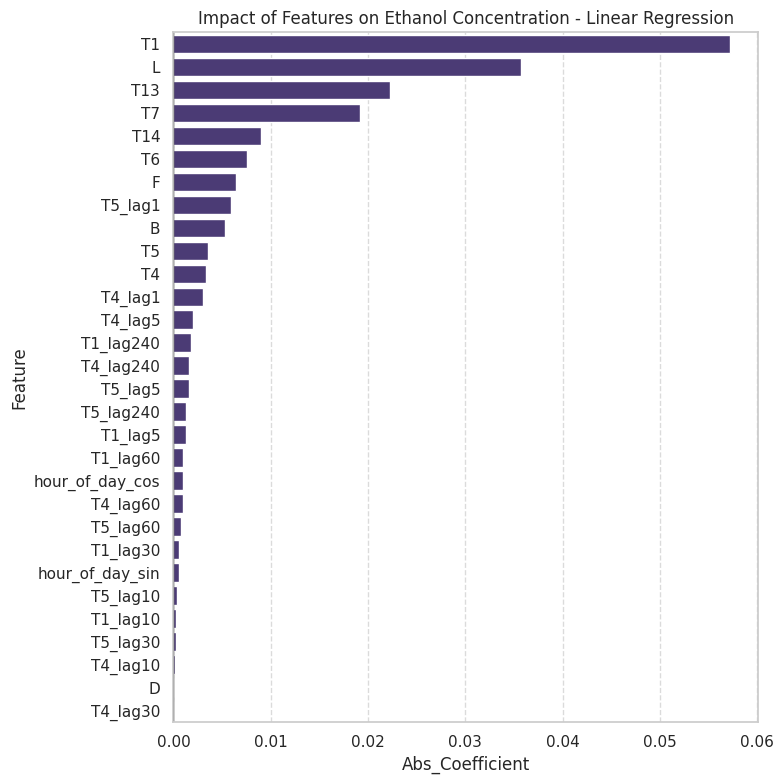

In [146]:
plt.figure(figsize=(8, 8))

sns.barplot(
    data=coef_df_lr, 
    x='Abs_Coefficient', 
    y='Feature', 
    legend=False
)

# Add a vertical line at 0 for clarity
plt.axvline(x=0, color='black', linestyle='-', linewidth=1)

plt.title('Impact of Features on Ethanol Concentration - Linear Regression', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
## Part 5: XGBoost Model

### 5.1 Understanding XGBoost Hyperparameters

**Key Hyperparameters:**
- `n_estimators`: Number of boosting rounds (trees). More = longer training, potentially better but risk of overfitting
- `max_depth`: Maximum depth of each tree. Deeper = more complex, captures more patterns, but overfits easier
- `learning_rate`: Shrinkage factor (0-1). How much each new tree contributes. Lower = slower learning but more stable
- `subsample`: Fraction of samples for training each tree (0-1). Lower = more regularization
- `colsample_bytree`: Fraction of features for training each tree (0-1). Lower = more regularization
- `reg_lambda`: L2 regularization. Higher = more penalty, prevents overfitting
- `reg_alpha`: L1 regularization. Higher = more penalty, encourages sparse features

**Questions for you:**
1. "If you increase n_estimators, what happens? (Better or worse generalization?)"
2. "If you increase max_depth, what happens to overfitting?"
3. "How do learning_rate and n_estimators interact?"
4. "What does regularization (lambda, alpha) do?"

### 5.2 Train XGBoost (Basic Configuration)

**What you need to do:**
1. Create XGBRegressor with reasonable default parameters
2. Train on X_train_scaled and y_train
3. Make predictions on X_test_scaled
4. Calculate metrics: RMSE, MAE, R²
5. Check for overfitting by comparing train vs test metrics

**Questions for you:**
1. "What hyperparameters should you start with?"
2. "If train RMSE=0.01 but test RMSE=0.05, what's happening?"
3. "How would you fix overfitting?"
4. "Should XGBoost beat Random Forest? By how much?"

In [147]:
xgb_reg = XGBRegressor()

xgb_reg.fit(X_train_scaled, y_train)

y_pred_xgb = xgb_reg.predict(X_test_scaled)

In [148]:
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
rmse_xgb = root_mean_squared_error(y_test, y_pred_xgb)

print(f"R2 Score: {r2_xgb:.4f}")
print(f"Mean Error: {mae_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.4f}")

R2 Score: 0.9998
Mean Error: 0.0008
RMSE: 0.0010


---
## Part 6: Feature Importance Analysis

### 6.1 Why Feature Importance Matters

**What you need to understand:**
- Feature importance tells you which features the model relies on MOST
- XGBoost calculates importance based on how much each feature reduces loss
- Helps you understand: "Does the model learn the physics or just correlations?"
- Guides domain understanding: "Are my lagged features more important than raw features?"

**Questions for you:**
1. "Which features do you EXPECT to be important? (Based on domain knowledge)"
2. "Do you expect lagged features to be more important than raw features? Why?"
3. "Do you expect cyclic encoded time (hour_sin, hour_cos) to matter? Why?"
4. "If a feature has zero importance, what does that mean?"

### 6.2 Extract and Visualize Feature Importance

**What you need to do:**
1. Extract feature importances from XGBoost model
2. Create a DataFrame with feature names and importances
3. Sort by importance (descending)
4. Plot top 20 features as a horizontal bar chart
5. Analyze: Do the top features make sense?

**Questions for you:**
1. "What are the top 5 most important features?"
2. "Are they what you expected?"
3. "Do lagged features dominate? Or raw features?"
4. "What does the importance distribution tell you about your model?"

In [98]:
coef_df_xgb = pd.DataFrame({
    'Feature': xgb_reg.feature_names_in_,
    'Importance': xgb_reg.feature_importances_
})

coef_df_xgb = coef_df_xgb.sort_values(by='Importance', ascending=False)

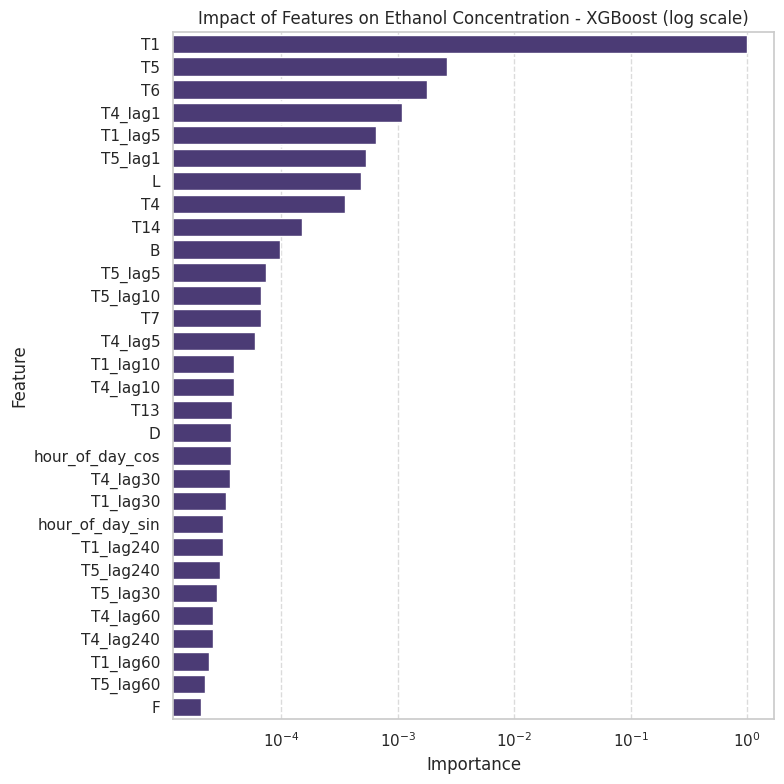

In [101]:
plt.figure(figsize=(8, 8))

sns.barplot(
    data=coef_df_xgb, 
    x='Importance', 
    y='Feature', 
    legend=False
)

plt.xscale('log')

plt.title('Impact of Features on Ethanol Concentration - XGBoost (log scale)', fontsize=12)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 6.3 Domain Knowledge Check

**What you need to think about:**
- Does the importance distribution make physical sense?
- Are temperature features important? (Yes, driving force for distillation)
- Are reflux features important? (Yes, controls separation)
- Are cyclic/time features important? (Expected: somewhat)
- Any surprising patterns?

**Questions for you:**
1. "Do the top features align with distillation thermodynamics?"
2. "If the most important feature is something unexpected, why might that be?"
3. "Would you trust this model to a distillation operator? Why or why not?"

---
## Part 7: Model Comparison & Visualization

### 7.1 Create Comprehensive Comparison Table

**What you need to do:**
1. Collect results from all models (Linear Reg, Random Forest, XGBoost)
2. Create a summary DataFrame with:
   - Model name
   - RMSE
   - MAE
   - R²
3. Sort by best metric (e.g., lowest RMSE)
4. Calculate improvement %: (baseline_rmse - xgb_rmse) / baseline_rmse * 100

**Questions for you:**
1. "Which model wins on RMSE?"
2. "By how much does XGBoost improve over the best baseline?"
3. "Is the improvement meaningful? (What % improvement would be 'good'?)"
4. "Why might the rankings differ for RMSE vs R²?"

In [161]:
comparison_df =  pd.DataFrame({"Linear Regression" : [r2_lr, mae_lr, rmse_lr],
                                "XGBoost" : [r2_xgb, mae_xgb, rmse_xgb],
                                "Improvement (%)" : [abs(((r2_xgb-r2_lr)/r2_lr)*100), 
                                                     abs(((mae_xgb-mae_lr)/mae_lr)*100), 
                                                     abs(((rmse_xgb-rmse_lr)/rmse_lr)*100)]},
                                index = ['r2', 'MAE', 'RMSE'])
comparison_df['Improvement (%)'] = comparison_df['Improvement (%)'].round(2)
comparison_df

,Linear Regression,XGBoost,Improvement (%)
r2,0.9859,0.9998,1.41
MAE,0.0062,0.0008,87.60
RMSE,0.0080,0.0010,87.32


### 7.2 Visualize Predictions vs Actual

**What you need to do:**
1. Create scatter plots: predicted vs actual for best 2-3 models
2. Add a perfect prediction line (diagonal)
3. Add titles, labels, and grid
4. Use subplots to compare multiple models

**What to look for:**
- Are predictions scattered around the diagonal? (Good)
- Are there systematic errors? (Bad — e.g., always overestimating)
- Are errors larger at high or low purity values? (Suggests model struggles with certain ranges)

**Questions for you:**
1. "Which model's predictions hug the diagonal most closely?"
2. "Are there any points far from the diagonal? What do they represent?"
3. "Does the model perform equally well at all purity ranges?"

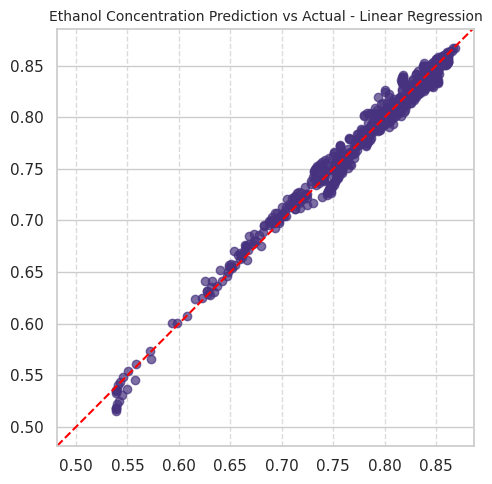

In [167]:
plt.figure(figsize=(5, 5))

plt.scatter(x=y_test, y=y_pred_lr, alpha=0.7)
plt.axline((0.5, 0.5), slope=1, color='red', linestyle='--', label='Ideal (x=y)')
plt.title('Ethanol Concentration Prediction vs Actual - Linear Regression', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

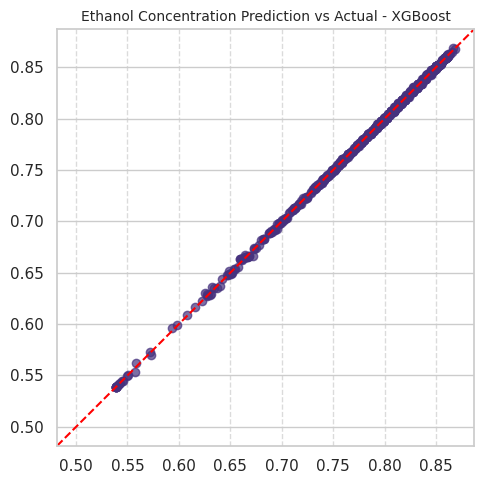

In [168]:
plt.figure(figsize=(5, 5))

plt.scatter(x=y_test, y=y_pred_xgb, alpha=0.7)
plt.axline((0.5, 0.5), slope=1, color='red', linestyle='--', label='Ideal (x=y)')
plt.title('Ethanol Concentration Prediction vs Actual - XGBoost', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

### 7.3 Analyze Residuals

**What you need to do:**
1. Calculate residuals: actual - predicted for best model
2. Create residual plots:
   - Histogram of residuals (should be normally distributed)
   - Scatter: predicted vs residuals (should be random cloud, no pattern)
   - Time series of residuals (should be random)

**What to look for:**
- Residuals centered at zero? (Good)
- Normally distributed? (Good for statistical inference)
- Any patterns? (Bad — suggests model is missing something)
- Larger errors at certain times? (Bad — model not stable over time)

**Questions for you:**
1. "Are residuals randomly distributed or do they show a pattern?"
2. "If residuals are larger at certain times, what could that mean?"
3. "If residuals are skewed (not symmetric), what does that suggest?"

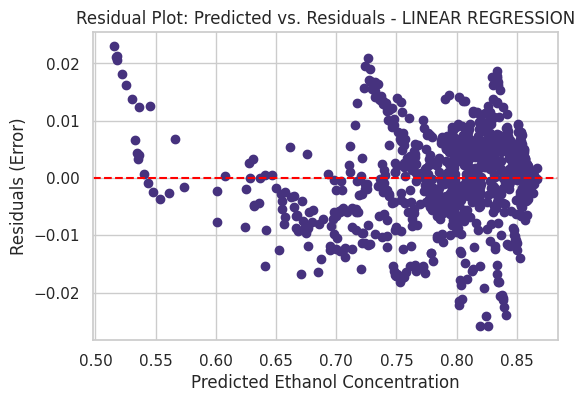

In [170]:
# 1. Calculate residuals
residuals_lr = y_test - y_pred_lr

# 2. Plot
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_lr, residuals_lr)
plt.axhline(y=0, color='red', linestyle='--') 
plt.title('Residual Plot: Predicted vs. Residuals - LINEAR REGRESSION')
plt.xlabel('Predicted Ethanol Concentration')
plt.ylabel('Residuals (Error)')
plt.show()

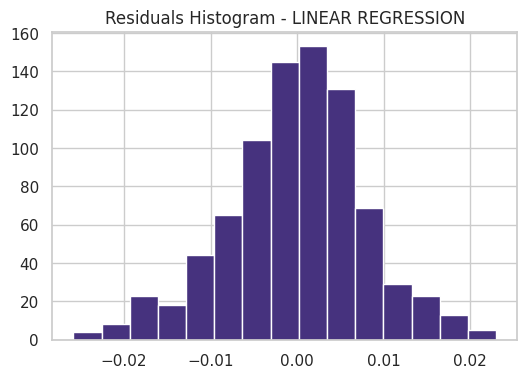

In [180]:
plt.figure(figsize=(6, 4))
plt.hist(residuals_lr, bins=15)
plt.title('Residuals Histogram - LINEAR REGRESSION')
plt.show()

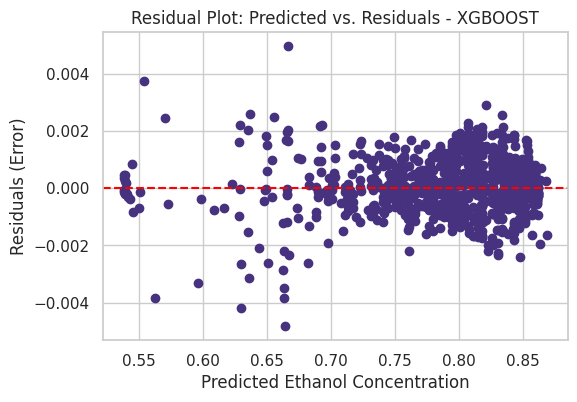

In [174]:
# 1. Calculate residuals
residuals_xgb = y_test.values.flatten() - y_pred_xgb.flatten()

# 2. Plot
plt.figure(figsize=(6, 4))
plt.scatter(y_pred_xgb, residuals_xgb)
plt.axhline(y=0, color='red', linestyle='--') 
plt.title('Residual Plot: Predicted vs. Residuals - XGBOOST')
plt.xlabel('Predicted Ethanol Concentration')
plt.ylabel('Residuals (Error)')
plt.show()

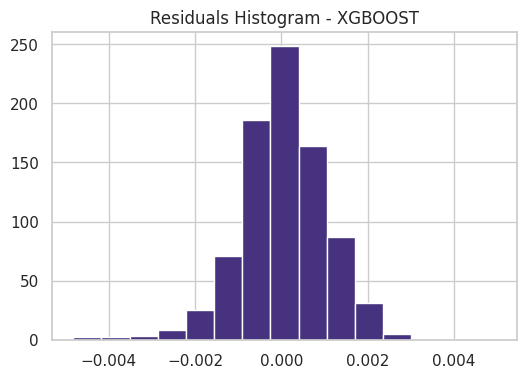

In [181]:
plt.figure(figsize=(6, 4))
plt.hist(residuals_xgb, bins=15)
plt.title('Residuals Histogram - XGBOOST')
plt.show()

### 7.4 Final Model Selection

**What you need to think about:**
- Is XGBoost significantly better than baselines?
- Is the improvement worth the added complexity?
- Are there any red flags in residual analysis?
- Would you recommend this model for production?

**Questions for you:**
1. "Which model would you choose to deploy? Why?"
2. "What are the trade-offs between simplicity (Linear Reg) and complexity (XGBoost)?"
3. "Are there any concerns about this model that you'd want to address?"
4. "How would you present this to a distillation plant operator?"

---
## Part 8: Save Models & Preprocessing Objects

### 8.1 Save Best Models for Deployment

In [189]:
joblib.dump(lr_model, ROOT / "models" / "lr_model.pkl")
joblib.dump(xgb_reg, ROOT / "models" / "xgb_model.pkl")

['/home/ildebrando/code/ijesusjr/000_DS_Portfolio/01_soft_sensor/models/xgb_model.pkl']

### 8.2 Verify Saved Objects

**What you need to do:**
1. Load the saved model back
2. Load the saved scaler back
3. Make a prediction on a sample from test set
4. Verify prediction matches what you got before saving

**Why?** To ensure saving/loading works correctly before deployment

**Questions for you:**
1. "Do the loaded model predictions match the original model predictions?"
2. "If they don't match exactly, why might that be? (floating point precision?)"
3. "What would you do if they don't match?"

In [192]:
# Loading models
scaler_test = joblib.load(ROOT / "models" / "scaler.pkl")
model_lr_test = joblib.load(ROOT / "models" / "lr_model.pkl")
model_xgb_test = joblib.load(ROOT / "models" / "xgb_model.pkl")


In [199]:
X_new = X_test.iloc[100:200]
y_new = y_test[100:200]

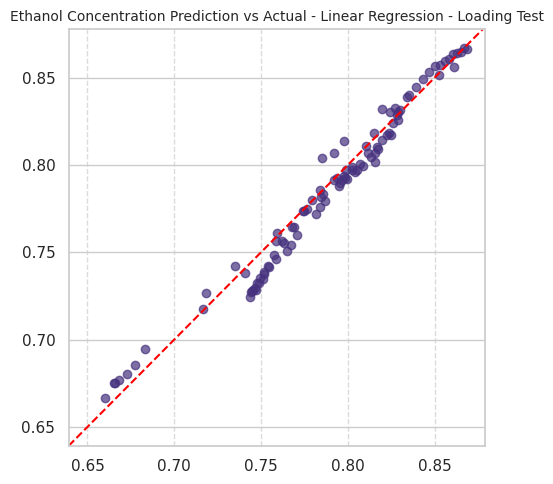

In [206]:
# Testing the loaded models with a fraction of test set

X_new_scaled = scaler_test.transform(X_new)
y_pred_lr_new = model_lr_test.predict(X_new_scaled)

plt.figure(figsize=(5, 5))

plt.scatter(x=y_new, y=y_pred_lr_new, alpha=0.7)
plt.axline((0.65, 0.65), slope=1, color='red', linestyle='--', label='Ideal (x=y)')
plt.title('Ethanol Concentration Prediction vs Actual - Linear Regression - Loading Test', fontsize=10)
plt.grid(axis='x', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()

---
## Summary & Key Takeaways

### What You've Done:

✅ **Loaded and prepared data** — scaled features properly (fit on train, transform test)

✅ **Built baselines** — Linear Regression and Random Forest for comparison

✅ **Trained XGBoost** — with reasonable hyperparameters, checked for overfitting

✅ **Analyzed feature importance** — understood which features the model relies on

✅ **Compared models** — chose the best performer

✅ **Analyzed residuals** — verified predictions make sense

✅ **Saved for production** — model and scaler ready to deploy

---

### Key Concepts to Remember:

1. **Chronological splits**: Never shuffle time-series data
2. **Fit on train, transform on test**: Prevent data leakage
3. **Baselines matter**: Your model must beat "simple" approaches
4. **Feature importance**: Tells you if model learned physics or just correlations
5. **Residual analysis**: Reveals if your model is missing patterns
6. **Save everything**: Model, scaler, feature names, metadata

---

### Next Steps:

Once you've completed this notebook:
1. Review your results — do they make sense?
2. Think about improvements — better hyperparameters? More features?
3. Prepare for deployment — create API/dashboard (next notebook)
4. Document findings — write up for portfolio/interviews